In [1]:
# IMPORTING OPERATING SYSTEM AND CHANGING THE WORKING DIRECTORY
import os 
os.chdir("C:\\Users\\LENOVO\\OneDrive\\Documents\\MKT DS PROJECTS\\Data")

In [48]:
# IMPORTING LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# 
with open('Student_data_files/sheet001.htm', 'r', encoding='utf-8') as file:
    soup = BeautifulSoup(file, 'html.parser')
print("File Loaded Successfully!")

File Loaded Successfully!


In [10]:
table = soup.find('table')
if table:
    print("Found The table! Here are the first few headers:")
    headers = [th.get_text(strip=True) for th in table.find_all('tr') [0].find_all('td')]
    print(headers)
else:
    print("File Opened, but I couldn't find the table. Check the HTML file.")

Found The table! Here are the first few headers:
['Student_ID', 'Gender', 'Age', 'Attendance_Rate', 'Study_Hours_Weekly', 'Parental_Support', 'Extracurricular_Activities', 'Internet_Access', 'Maths_Score', 'English_Score', 'Science_Score', 'Average_Score', 'Performance_Category']


In [14]:
# LOADING THE DATASET
df = pd.read_excel('Student_data.xlsx')

print(f"Original Data Shape: {df.shape}")

Original Data Shape: (200, 13)


In [15]:
df

,Student_ID,Gender,Age,Attendance_Rate,Study_Hours_Weekly,Parental_Support,Extracurricular_Activities,Internet_Access,Maths_Score,English_Score,Science_Score,Average_Score,Performance_Category
0,STU001,Female,22,97.62,25,Low,Yes,Yes,81,83,86,83.33,Excellent
1,STU002,Female,23,90.38,8,Medium,Yes,Yes,45,78,73,65.33,Average
2,STU003,Male,19,96.56,12,Medium,Yes,Yes,90,62,46,66.00,Average
3,STU004,Female,24,77.74,21,Low,Yes,Yes,93,77,61,77.00,Good
4,STU005,Female,16,81.12,19,High,Yes,Yes,55,56,93,68.00,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,STU196,Male,16,92.09,25,Medium,Yes,No,69,46,91,68.67,Average
196,STU197,Male,21,70.95,13,Low,Yes,No,94,98,89,93.67,Excellent
197,STU198,Male,23,82.29,5,High,Yes,No,62,51,89,67.33,Average
198,STU199,Male,20,85.36,25,High,No,Yes,56,83,100,79.67,Good


In [18]:
# HANDLING MISSING VALUE
df.fillna({'Attendance_Rate': df['Attendance_Rate'].median(), 'Study_Hours_Weekly': df['Study_Hours_Weekly'].median()}, inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  200 non-null    object 
 1   Gender                      200 non-null    object 
 2   Age                         200 non-null    int64  
 3   Attendance_Rate             200 non-null    float64
 4   Study_Hours_Weekly          200 non-null    int64  
 5   Parental_Support            200 non-null    object 
 6   Extracurricular_Activities  200 non-null    object 
 7   Internet_Access             200 non-null    object 
 8   Maths_Score                 200 non-null    int64  
 9   English_Score               200 non-null    int64  
 10  Science_Score               200 non-null    int64  
 11  Average_Score               200 non-null    float64
 12  Performance_Category        200 non-null    object 
dtypes: float64(2), int64(5), object(6)


In [21]:
df.isna().sum().sum()

0

In [22]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [23]:
df.duplicated().sum()

0

In [24]:
df.describe()

,Age,Attendance_Rate,Study_Hours_Weekly,Maths_Score,English_Score,Science_Score,Average_Score
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000,200.000000
mean,20.320000,84.656900,14.965000,67.715000,69.90000,68.25500,68.623150
std,3.252768,8.515051,6.242485,19.556484,18.73781,18.22583,10.186479
min,15.000000,70.100000,5.000000,35.000000,40.00000,38.00000,46.000000
25%,17.000000,77.347500,10.000000,52.000000,53.75000,52.00000,61.247500
50%,21.000000,85.175000,15.000000,67.000000,70.00000,67.00000,69.000000
75%,23.000000,92.387500,21.000000,85.250000,87.25000,85.00000,76.082500
max,25.000000,97.900000,25.000000,100.000000,100.00000,100.00000,96.000000


In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df

,Student_ID,Gender,Age,Attendance_Rate,Study_Hours_Weekly,Parental_Support,Extracurricular_Activities,Internet_Access,Maths_Score,English_Score,Science_Score,Average_Score,Performance_Category
0,STU001,Female,22,97.62,25,Low,Yes,Yes,81,83,86,83.33,Excellent
1,STU002,Female,23,90.38,8,Medium,Yes,Yes,45,78,73,65.33,Average
2,STU003,Male,19,96.56,12,Medium,Yes,Yes,90,62,46,66.00,Average
3,STU004,Female,24,77.74,21,Low,Yes,Yes,93,77,61,77.00,Good
4,STU005,Female,16,81.12,19,High,Yes,Yes,55,56,93,68.00,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,STU196,Male,16,92.09,25,Medium,Yes,No,69,46,91,68.67,Average
196,STU197,Male,21,70.95,13,Low,Yes,No,94,98,89,93.67,Excellent
197,STU198,Male,23,82.29,5,High,Yes,No,62,51,89,67.33,Average
198,STU199,Male,20,85.36,25,High,No,Yes,56,83,100,79.67,Good


In [27]:
# CREATING NEW FEATURES
# CALCULATING TOTAL SCORE
df['Total_Score'] = df['Maths_Score'] + df['English_Score'] + df['Science_Score']

In [29]:
# CREATING HIGH ATTENDANCE
df['Has_High_Attendance'] = df['Study_Hours_Weekly'] >= 85

# CREATINGCD STUDIES ADEQUATELY
df['Studies_Adequately'] = df['Study_Hours_Weekly'] >= 15

In [30]:
# DEFFINING FUNCTION TO GRADE THE SCORES
def get_subject_category(Score):
    if Score >= 80: 
        return 'Excellent'
    elif Score >= 70:
        return 'Good'
    elif Score >= 50: 
        return 'Average'
    else:
        return 'Poor'

# APPLYING THE FUNCTION TO EACH SUBJECT
df['Maths_Category'] = df['Maths_Score'].apply(get_subject_category)
df['English_Category'] = df['English_Score'].apply(get_subject_category)
df['Science_Category'] = df['Science_Score'].apply(get_subject_category)

In [31]:
# SAVING THE CLEANED DATA 
df.to_excel('Cleaned_Student_Data.xlsx', index=False)
print("\n Data Cleaning Completed!")
print(f"Final Data Shape: {df.shape}")
print("Saved new file: 'Cleaned_Student_data.xlsx'")


 Data Cleaning Completed!
Final Data Shape: (200, 19)
Saved new file: 'Cleaned_Student_data.xlsx'


In [32]:
print(df[['Student_ID', 'Total_Score', 'Maths_Category', 'Has_High_Attendance']])

    Student_ID  Total_Score Maths_Category  Has_High_Attendance
0       STU001          250      Excellent                False
1       STU002          196           Poor                False
2       STU003          198      Excellent                False
3       STU004          231      Excellent                False
4       STU005          204        Average                False
..         ...          ...            ...                  ...
195     STU196          206        Average                False
196     STU197          281      Excellent                False
197     STU198          202        Average                False
198     STU199          239        Average                False
199     STU200          225      Excellent                False

[200 rows x 4 columns]


# COMPREHENSIVE ANALYSIS

In [36]:
df = pd.read_excel('Cleaned_Student_data.xlsx')
df

,Student_ID,Gender,Age,Attendance_Rate,Study_Hours_Weekly,Parental_Support,Extracurricular_Activities,Internet_Access,Maths_Score,English_Score,Science_Score,Average_Score,Performance_Category,Total_Score,Has_High_Attendance,Studies_Adequately,Maths_Category,English_Category,Science_Category
0,STU001,Female,22,97.62,25,Low,Yes,Yes,81,83,86,83.33,Excellent,250,False,True,Excellent,Excellent,Excellent
1,STU002,Female,23,90.38,8,Medium,Yes,Yes,45,78,73,65.33,Average,196,False,False,Poor,Good,Good
2,STU003,Male,19,96.56,12,Medium,Yes,Yes,90,62,46,66.00,Average,198,False,False,Excellent,Average,Poor
3,STU004,Female,24,77.74,21,Low,Yes,Yes,93,77,61,77.00,Good,231,False,True,Excellent,Good,Average
4,STU005,Female,16,81.12,19,High,Yes,Yes,55,56,93,68.00,Average,204,False,True,Average,Average,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,STU196,Male,16,92.09,25,Medium,Yes,No,69,46,91,68.67,Average,206,False,True,Average,Poor,Excellent
196,STU197,Male,21,70.95,13,Low,Yes,No,94,98,89,93.67,Excellent,281,False,False,Excellent,Excellent,Excellent
197,STU198,Male,23,82.29,5,High,Yes,No,62,51,89,67.33,Average,202,False,False,Average,Average,Excellent
198,STU199,Male,20,85.36,25,High,No,Yes,56,83,100,79.67,Good,239,False,True,Average,Excellent,Excellent


In [40]:
print("=== 1. BASIC STATISTICS ===")
# CALCULATE AND PRINT AVERAGES
print(f"Total Students: {len(df)}")
print(f"Average Maths Score: {df['Maths_Score'].mean(): .2f}")
print(f"Average English Score: {df['English_Score'].mean(): .2f}")
print(f"Average Science Score: {df['Science_Score'].mean(): .2f}")
print(f"Overall Average: {df['Average_Score'].mean(): .2f}")

print("\nPerformance Distribution:")
print(df['Performance_Category'].value_counts())

=== 1. BASIC STATISTICS ===
Total Students: 200
Average Maths Score:  67.72
Average English Score:  69.90
Average Science Score:  68.25
Overall Average:  68.62

Performance Distribution:
Performance_Category
Average              100
Good                  69
Excellent             25
Needs Improvement      6
Name: count, dtype: int64


In [43]:
print("\n=== 2. CORRELATION ANALYSIS ===")
Numerical_Cols = ['Attendance_Rate', 'Study_Hours_Weekly', 'Age','Maths_Score','English_Score','Science_Score','Average_Score']

# CALCULATING CORRELATION MATRIX
correlation_matrix = df[Numerical_Cols].corr()

# SHOWING WHAT AFFECTS THE AVERAGE SCORE THE MOST
print(correlation_matrix['Average_Score'].sort_values(ascending=False))


=== 2. CORRELATION ANALYSIS ===
Average_Score         1.000000
Maths_Score           0.609313
English_Score         0.530076
Science_Score         0.477966
Study_Hours_Weekly    0.144944
Age                   0.115328
Attendance_Rate       0.005375
Name: Average_Score, dtype: float64


In [45]:
print("\n=== 3. PERFORMANCE BY FACTORS ===") 
# ANALYZING GENDER
print("\n Average Score by Gender:")
print(df.groupby('Gender')['Average_Score'].mean())

# ANALYZING PARENTAL SUPPORT
print("\n Average Score by Parental Support:")
print(df.groupby('Parental_Support')['Average_Score'].mean())


=== 3. PERFORMANCE BY FACTORS ===

 Average Score by Gender:
Gender
Female    68.47602
Male      68.76451
Name: Average_Score, dtype: float64

 Average Score by Parental Support:
Parental_Support
High      68.076143
Low       69.564308
Medium    68.271077
Name: Average_Score, dtype: float64


In [46]:
print("\n=== 4. STATISTICAL TESTS ===")
# T-TEST: DOES GENDER MAKE A SIGNIFIICANT DIFFERENCE?
Male_Scores = df[df['Gender'] == 'Male']['Average_Score']
Female_Scores = df[df['Gender'] == 'Female']['Average_Score']

t_stat, p_value = stats.ttest_ind(Male_Scores, Female_Scores)
print(f"T-test between Genders: \n t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")

# INTERPRETATION
if p_value < 0.05:
    print("Result: Significant difference found between genders.")
else:
    print("Result: No significant differnce found between genders.")


=== 4. STATISTICAL TESTS ===
T-test between Genders: 
 t-statistic = 0.200, p-value = 0.842
Result: No significant differnce found between genders.


In [47]:
print("\n Analysis Completed")


 Analysis Completed


# VISUALIZATION 

In [50]:
# LOADING THE CLEANED DATA
df = pd.read_excel('Cleaned_Student_Data.xlsx')
print("Data loaded Successfully!")

Data loaded Successfully!


In [51]:
# SETTING THE ARTISTIS STYLE
plt.style.use('ggplot')
sns.set_palette("husl")

Generating Pie Chart....


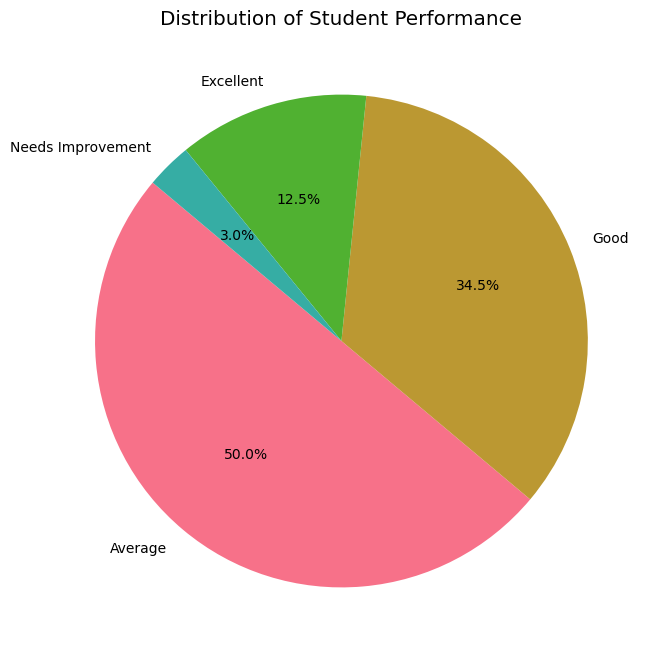

In [53]:
# ----- VISUALIZATION  1: Performance Pie Chart -----
print("Generating Pie Chart....")
plt.figure(figsize=(8, 8))

# Counting How Many Students are in each category
counts = df['Performance_Category'].value_counts()

plt.pie(counts, labels=counts.index,autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Student Performance')
plt.savefig('1_Performance_Pie.png')
plt.show()

Generating Scatter Plot...


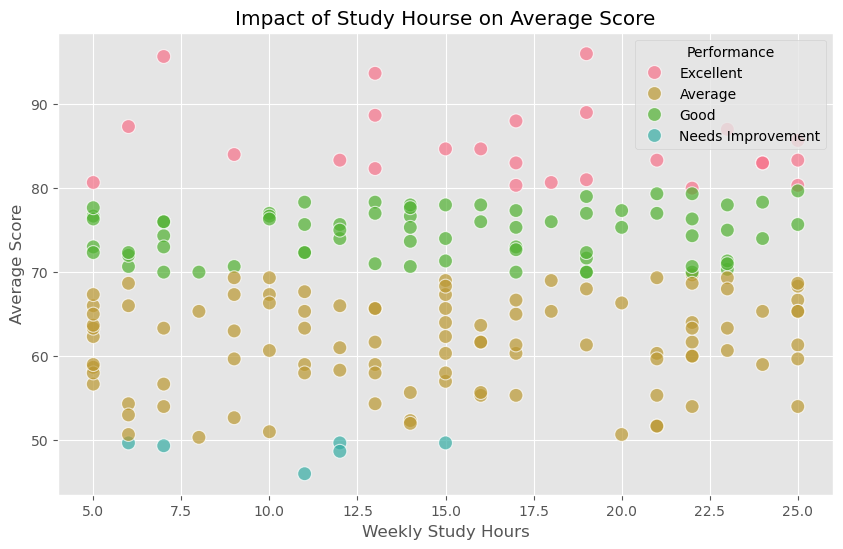

In [55]:
# ---- VISUALIZATION 2: STUDY HOURS VS. SCORE(SCATTER PLOT) ----
print("Generating Scatter Plot...")
plt.figure(figsize=(10, 6))

# SCATTER PLOT SHOWING RELATIONSHIP BETTWEEN STUDYING AND GRADES
sns.scatterplot(data=df, x='Study_Hours_Weekly', y='Average_Score', hue='Performance_Category', s=100, alpha=0.7)

plt.title('Impact of Study Hourse on Average Score')
plt.xlabel('Weekly Study Hours')
plt.ylabel('Average Score')
plt.legend(title='Performance')
plt.savefig('2_Study_Vs_Score.png')
plt.show()

Generating Heatmap...


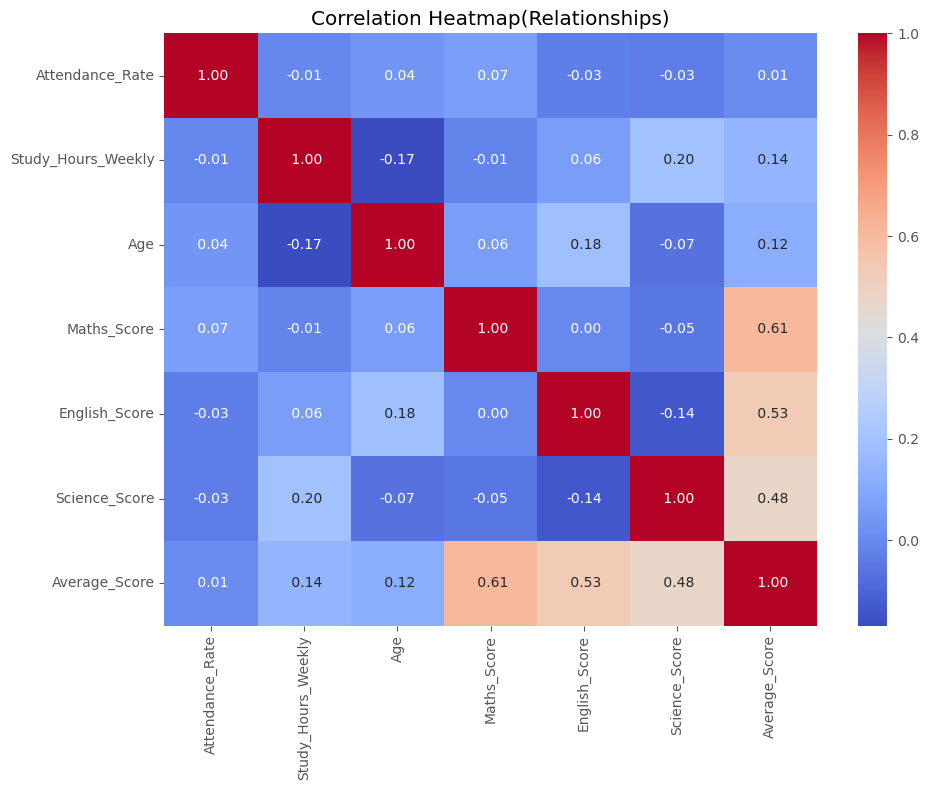

In [62]:
# ---- VISUALIZATIO 3: CORRELATION HEATMAP ----
print("Generating Heatmap...")
plt.figure(figsize=(10, 8))

# SELECT ONLY NUMBER COLUMNS FOR CORRELATION
Numerical_Cols = ['Attendance_Rate', 'Study_Hours_Weekly', 'Age', 'Maths_Score', 'English_Score', 'Science_Score', 'Average_Score']

# CREATE THE CORRELATION MATRIX
corr_matrix = df[Numerical_Cols].corr()

# DRAWING THE HEATMAP
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=' .2f')
plt.title('Correlation Heatmap(Relationships)')
plt.tight_layout()
plt.savefig('3_Correlation_Heat_Map.png')
plt.show()

Generating Bar Chart...


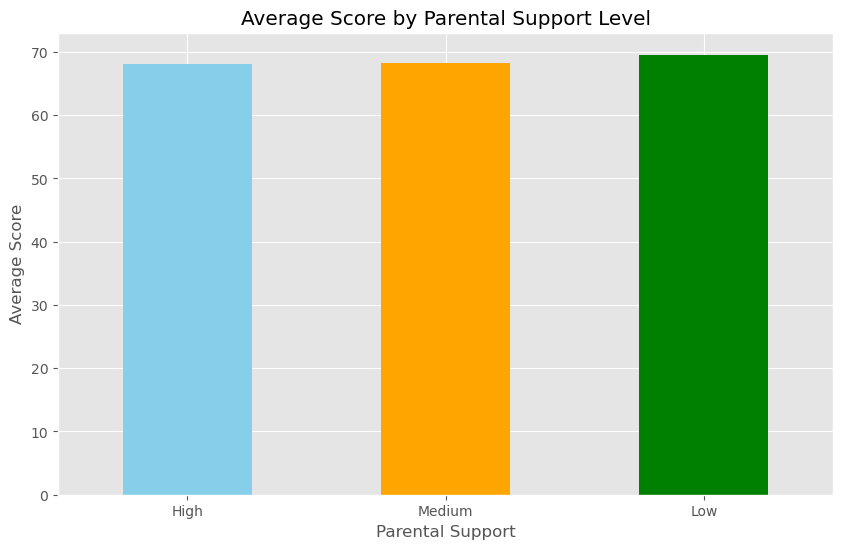

In [64]:
# ---- VISUALIZATION 4: PARENTAL SUPPORT IMPACT (BAR CHART) ----
print("Generating Bar Chart...")
plt.figure(figsize=(10, 6))

# Group by Support Level and Get the Average Score
Support_impact = df.groupby('Parental_Support')['Average_Score'].mean().sort_values()

# Draw the Bar Chart
Support_impact.plot(kind='bar',color=['skyblue', 'orange', 'green'])
plt.title('Average Score by Parental Support Level')
plt.ylabel('Average Score')
plt.xlabel('Parental Support')
plt.xticks(rotation=0)
plt.savefig('4_Parental_Support.png')
plt.show()

In [65]:
print("\n PROJECT COMPLETEDE, CHEERS!!!!")


 PROJECT COMPLETEDE, CHEERS!!!!
